# PyTorch tensors and NumPy arrays

Pytorch is extremly similar to NumPy, it is essentially a small upgrade on it to support training AI models in a more convinient way.

PyTorch adds two capabilities needed for deep learning:

1. Tensors can run on accelerators such as NVIDIA CUDA and Intel XPU devices.
2. PyTorch can automatically calculate gradients for training models.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")

NumPy:  2.5.2
PyTorch: 2.13.0+cu130


## Creating arrays and tensors

The APIs and printed values are intentionally similar. One small difference is the default floating-point type: NumPy normally creates `float64` values, while PyTorch normally uses `float32`, which is faster and smaller for neural networks.

In [2]:
numpy_array = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
torch_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)

print(numpy_array)
print(torch_tensor)
print(torch.from_numpy(numpy_array))

[[1. 2. 3.]
 [4. 5. 6.]]
tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])


In [3]:
print("NumPy shape/dtype: ", numpy_array.shape, numpy_array.dtype)
print("PyTorch shape/dtype:", torch_tensor.shape, torch_tensor.dtype)
print("PyTorch device:     ", torch_tensor.device)

NumPy shape/dtype:  (2, 3) float32
PyTorch shape/dtype: torch.Size([2, 3]) torch.float32
PyTorch device:      cpu


PyTorch also provides creation functions corresponding closely to NumPy's.
As a general rule code from either can be swaped around with minimal changes.

In [4]:
print("NumPy zeros:\n", np.zeros((2, 3)))
print("PyTorch zeros:\n", torch.zeros((2, 3)))

print("NumPy range: ", np.arange(0, 10, 2))
print("PyTorch range:", torch.arange(0, 10, 2))

print("NumPy random: ", np.random.default_rng(42).random(3))
generator = torch.Generator().manual_seed(42)
print("PyTorch random:", torch.rand(3, generator=generator))

NumPy zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
PyTorch zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
NumPy range:  [0 2 4 6 8]
PyTorch range: tensor([0, 2, 4, 6, 8])
NumPy random:  [0.77395605 0.43887844 0.85859792]
PyTorch random: tensor([0.8823, 0.9150, 0.3829])


In [5]:
print("Second row:       ", torch_tensor[1])
print("First column:     ", torch_tensor[:, 0])
print("Values above 3:   ", torch_tensor[torch_tensor > 3])
print("Reshaped to 3 x 2:\n", torch_tensor.reshape(3, 2))

Second row:        tensor([4., 5., 6.])
First column:      tensor([1., 4.])
Values above 3:    tensor([4., 5., 6.])
Reshaped to 3 x 2:
 tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])


In [6]:
offset = torch.tensor([10, 20, 30])

# The length-3 vector is broadcast across both rows.
print(torch_tensor + offset)

tensor([[11., 22., 33.],
        [14., 25., 36.]])


In [7]:
print("Element-wise square:\n", torch_tensor**2)
print("Mean:", torch_tensor.mean())
print("Column sums:", torch_tensor.sum(axis=0))

weights = torch.tensor([[0.5], [1.0], [-0.5]])
print("Matrix multiplication:\n", torch_tensor @ weights)

Element-wise square:
 tensor([[ 1.,  4.,  9.],
        [16., 25., 36.]])
Mean: tensor(3.5000)
Column sums: tensor([5., 7., 9.])
Matrix multiplication:
 tensor([[1.],
        [4.]])


## What tensors add: automatic differentiation

### Devices
generally we want to run models on GPU, it is more or less a straight performance win.
While the exact details as to WHY are complicated doing it is easy.

we choose a device to run on (usually at the start of the notebook). and then we move Tensors to that device before we start computing. pytorch would keep all of the results on the GPU for us already

In [8]:
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
print(f"Using: {device}")

Using: cuda


In [9]:
source_array = np.array([1.0, 2.0, 3.0], dtype=np.float32)
shared_tensor = torch.from_numpy(source_array)

shared_tensor[0] = 99
print("NumPy sees the change:", source_array)

back_to_numpy = shared_tensor.numpy()
print("Back to NumPy:       ", back_to_numpy)

NumPy sees the change: [99.  2.  3.]
Back to NumPy:        [99.  2.  3.]


In [10]:
accelerated_tensor = torch_tensor.to(device)
result = accelerated_tensor @ weights.to(device)

print("Calculation device:", result.device)

# NumPy only accepts CPU data, so move the result back first.
result_as_numpy = result.cpu().numpy()
print(result_as_numpy)

Calculation device: cuda:0
[[1.]
 [4.]]


### Plotting a function and its derivative
Pytorch can track gradients for us automatically, even when computation os somewhat complex

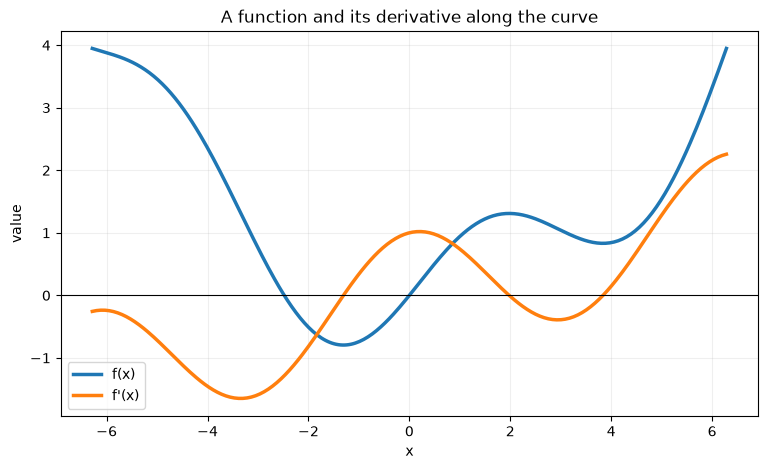

In [11]:
def func1(x):
    return torch.sin(x)

def function(x):
    return func1(x) + 0.1 * x**2

x_curve = torch.linspace(-2 * torch.pi, 2 * torch.pi, 300)
y_curve = torch.vmap(function)(x_curve)
derivative_function = torch.func.grad(function)
dy_dx_curve = torch.vmap(derivative_function)(x_curve)

plt.figure(figsize=(9, 5))
plt.plot(x_curve, y_curve, linewidth=2.5, label=r"f(x)")
plt.plot(x_curve, dy_dx_curve, linewidth=2.5, label=r"f'(x)")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("value")
plt.title("A function and its derivative along the curve")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

A slightly more realistic example computes the gradient of mean squared error for a one-parameter model $prediction = weight \times input$.

gradients are the version of derivatives generlized to higher dimentions (you shoud? know about them from math classes, anyone doing diffrential equations or calc3 would have to do them)

They are extremly important to what we do here, so you may want to brash up on the math

In [12]:
inputs = torch.tensor([1.0, 2.0, 3.0])
targets = torch.tensor([2.0, 4.0, 6.0])
weight = torch.tensor(1.0, requires_grad=True)

predictions = weight * inputs
loss = ((predictions - targets) ** 2).mean()
loss.backward()

print(f"Loss: {loss.item():.3f}")
print(f"Gradient for weight: {weight.grad.item():.3f}")

Loss: 4.667
Gradient for weight: -9.333


# Classifying points with neural networks

We will build a sequence of binary classifiers. Each CSV contains two input columns (`x1` and `x2`) and a `class` column containing either 0 or 1.

Our first step with a new dataset is always to plot it. When possible you always want to visualize what you can. Here we are lucky enough where everything fits nicely in one image

## Example 1: one linear decision boundary

Load and display the points before choosing a model.

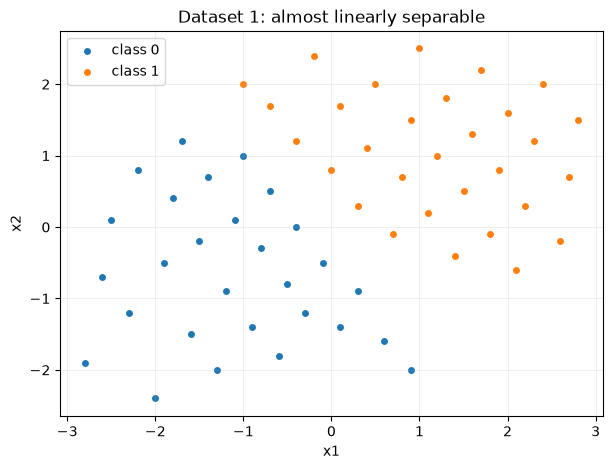

In [13]:
linear_data = pd.read_csv("data1_linear.csv")

def display_points(data, title, ax=None):
    own_figure = ax is None
    if own_figure:
        _, ax = plt.subplots(figsize=(7, 5))

    for label, colour in [(0, "tab:blue"), (1, "tab:orange")]:
        rows = data[data["class"] == label]
        ax.scatter(rows["x1"], rows["x2"], c=colour, label=f"class {label}", edgecolors="white")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

    if own_figure:
        plt.show()

display_points(linear_data, "Dataset 1: almost linearly separable")

There is a pretty obvious linear line between the 2 classes. could find it with normal logistic regression.
we will basically take the output of a linear model and run sigmoid on it.

```
Sigmoid(x) = 1/(1+e^-x)
```

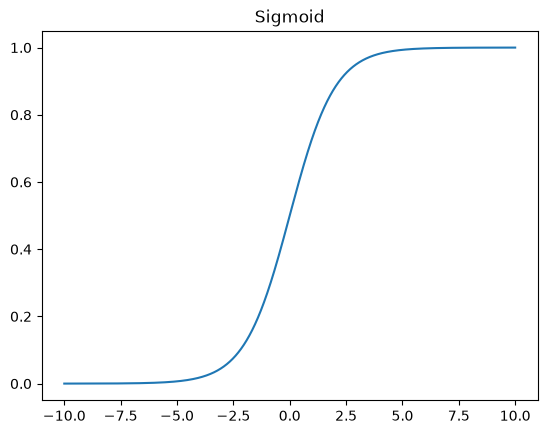

In [14]:
x = torch.linspace(-10, 10, 10000)
y = x.sigmoid()

plt.plot(x, y)
plt.title("Sigmoid")
plt.show()

final loss: 0.0170
accuracy:   100.0%


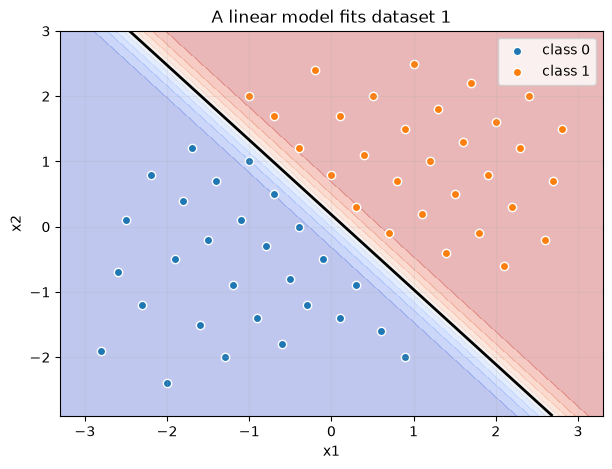

In [15]:
torch.manual_seed(42)
linear_model = nn.Linear(2, 1)

def train_model(model, data, epochs=500, learning_rate=0.03):
    features = torch.tensor(data[["x1", "x2"]].values, dtype=torch.float32)
    targets = torch.tensor(data["class"].values, dtype=torch.float32).reshape(-1, 1)
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for _ in range(epochs):
        optimizer.zero_grad()
        loss = loss_function(model(features), targets)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        predictions = (torch.sigmoid(model(features)) >= 0.5).float()
        accuracy = (predictions == targets).float().mean().item()

    print(f"final loss: {loss.item():.4f}")
    print(f"accuracy:   {accuracy:.1%}")

train_model(linear_model, linear_data)



def display_classifications(model, data, title):
    x1 = np.linspace(data["x1"].min() - 0.5, data["x1"].max() + 0.5, 250)
    x2 = np.linspace(data["x2"].min() - 0.5, data["x2"].max() + 0.5, 250)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)
    grid = torch.tensor(np.column_stack((grid_x1.ravel(), grid_x2.ravel())), dtype=torch.float32)

    with torch.no_grad():
        probabilities = torch.sigmoid(model(grid)).numpy().reshape(grid_x1.shape)

    _, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(grid_x1, grid_x2, probabilities, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(grid_x1, grid_x2, probabilities, levels=[0.5], colors="black", linewidths=2)
    display_points(data, title, ax=ax)
    plt.show()

display_classifications(linear_model, linear_data, "A linear model fits dataset 1")

## Example 2: data that needs a nonlinear boundary

Again, we load and plot the data before choosing a model.

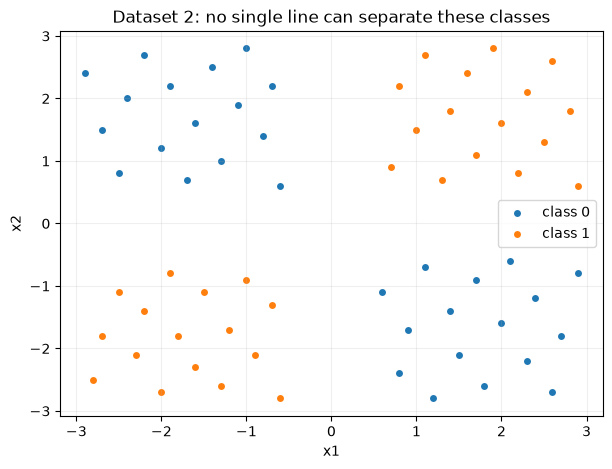

In [16]:
nonlinear_data = pd.read_csv("data2_nonlinear.csv")
display_points(nonlinear_data, "Dataset 2: no single line can separate these classes")

The classes form an XOR pattern: class 0 occupies the top-left and bottom-right, while class 1 occupies the other two regions. Wherever we place one straight line, some points must remain on the wrong side.

### First attempt: two linear layers, but no activation

It is tempting to expect two layers to solve a more complex problem. However, applying one linear transformation after another is still only a linear transformation:

$$W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1 + b_2)$$

The hidden layer has added parameters, but it has not added a bend to the decision boundary.

final loss: 0.6928
accuracy:   50.0%


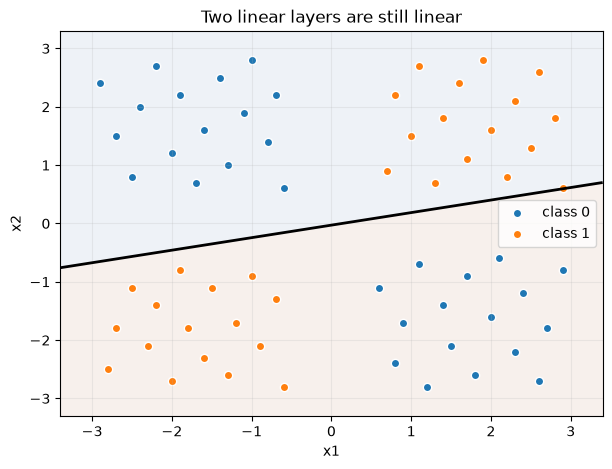

In [17]:
torch.manual_seed(42)
two_linear_layers = nn.Sequential(
    nn.Linear(2, 8),
    nn.Linear(8, 1),
)
train_model(two_linear_layers, nonlinear_data)
display_classifications(two_linear_layers, nonlinear_data, "Two linear layers are still linear")

### Second attempt: put ReLU between the layers

ReLU applies $\max(0, x)$ to each hidden value. It is simple, but importantly it is **nonlinear**. The first layer can now create several useful regions, ReLU clips each region at zero, and the final layer combines those pieces into a boundary that is not restricted to one straight line.

The number of trainable layers has not changed. The crucial change is the nonlinear activation between them.

final loss: 0.0002
accuracy:   100.0%


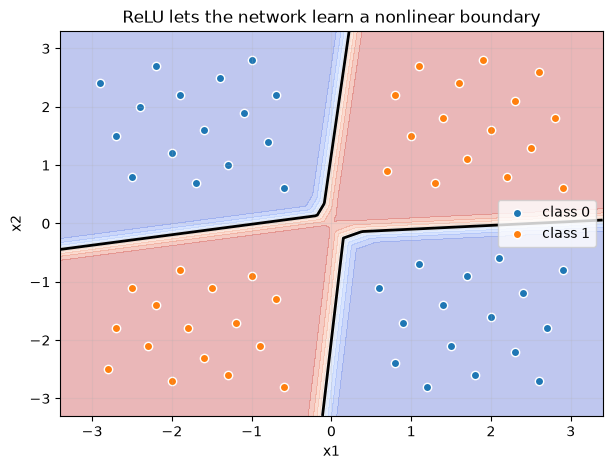

In [18]:
torch.manual_seed(42)
relu_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)
train_model(relu_model, nonlinear_data, epochs=800)
display_classifications(relu_model, nonlinear_data, "ReLU lets the network learn a nonlinear boundary")

## Assignment: classify the spiral

First, load and inspect a more difficult dataset.

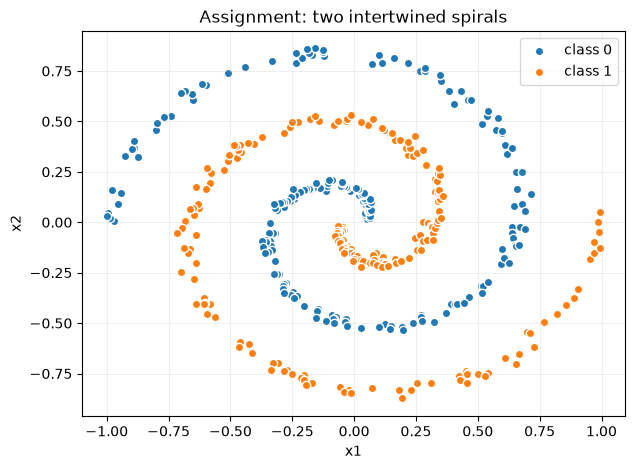

In [19]:
spiral_data = pd.read_csv("data3_spiral.csv")
display_points(spiral_data, "Assignment: two intertwined spirals")

### Your task

A straight line cannot separate these two spirals. Complete `spiral_model` below, then use the provided training and display calls to test it.

Your model must:

1. Accept the two coordinates `x1` and `x2`.
2. Return one logit for binary classification.
3. Use nonlinear activation functions between linear layers.
4. Reach at least 95% accuracy.

Experiment with the number of layers and the width of each layer. Run the cell only after adding layers to the empty model.

In [ ]:
torch.manual_seed(42)
spiral_model = nn.Sequential(
    # Add your layers here.

)

train_model(spiral_model, spiral_data, epochs=2000, learning_rate=0.02)
display_classifications(spiral_model, spiral_data, "Your spiral classifier")

# Independent Play

There is a program here called cool.py. If you run it with UV it will open an interactive training enviorment.

1. you can place points with left/right click
2. you can run training by holding space
3. C will clear the points
4. R will clear the models weights

Try out a few more examples yourself